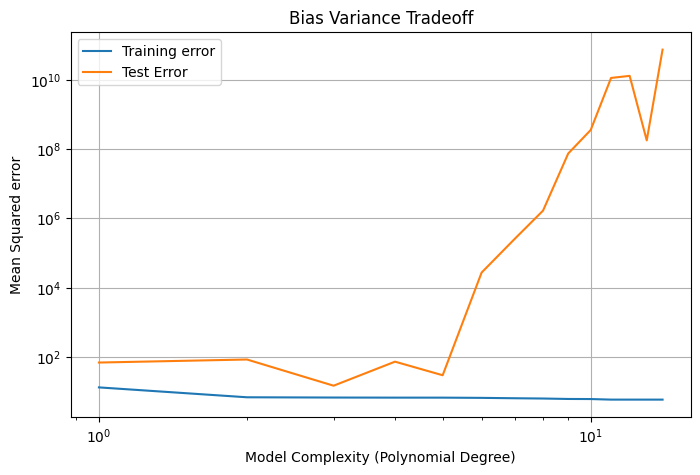

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

np.random.seed(42) 

# true function 
x = np.linspace(-3, 3, 100)
y = 0.5 * x**3 - x**2 + x + np.random.randn(100) *3

# Test train split 
x_train, x_test = x[:70], x[70:]
y_train, y_test = y[:70], y[70:]

def polynomial_features(x, degree):
    return np.vstack([x**i for i in range(degree+1)]).T 

def train_and_evaluate(degree):
    xtr = polynomial_features(x_train, degree)
    xte = polynomial_features(x_test, degree) 

    w = np.linalg.pinv(xtr) @ y_train 

    ytr_pred = xtr @ w 
    yte_pred = xte @ w 

    train_error = np.mean((y_train - ytr_pred)**2)
    test_error = np.mean((y_test - yte_pred)**2)

    return train_error, test_error 


degrees = range(1, 15) 
train_errors = [] 
test_errors = [] 

for d in degrees :
    tr_err , te_err = train_and_evaluate(d) 
    train_errors.append(tr_err) 
    test_errors.append(te_err) 


plt.figure(figsize=(8, 5))
plt.loglog(degrees, train_errors, label = "Training error")
plt.loglog(degrees, test_errors, label = "Test Error")

plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared error")
plt.title("Bias Variance Tradeoff")
plt.legend() 
plt.grid(True) 
plt.show() 

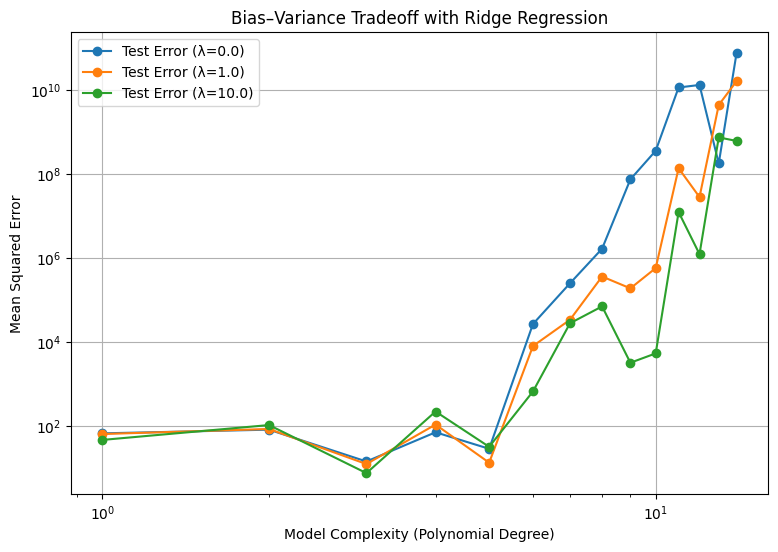

In [4]:
# Using Ridge regression 

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(-3, 3, 100)
y = 0.5 * X**3 - X**2 + X + np.random.randn(100) * 3

X_train, X_test = X[:70], X[70:]
y_train, y_test = y[:70], y[70:]


def polynomial_features(x, degree):
    return np.vstack([x**i for i in range(degree + 1)]).T

def ridge_train_and_evaluate(degree, alpha):
    Xtr = polynomial_features(X_train, degree)
    Xte = polynomial_features(X_test, degree)

    # Identity matrix (do NOT regularize bias)
    I = np.eye(Xtr.shape[1])
    I[0, 0] = 0

    # Ridge normal equation
    w = np.linalg.inv(Xtr.T @ Xtr + alpha * I) @ Xtr.T @ y_train

    ytr_pred = Xtr @ w
    yte_pred = Xte @ w

    train_error = np.mean((y_train - ytr_pred) ** 2)
    test_error = np.mean((y_test - yte_pred) ** 2)

    return train_error, test_error



degrees = range(1, 15)
alphas = [0.0, 1.0, 10.0]  # λ values

results = {}

for alpha in alphas:
    train_errors = []
    test_errors = []

    for d in degrees:
        tr_err, te_err = ridge_train_and_evaluate(d, alpha)
        train_errors.append(tr_err)
        test_errors.append(te_err)

    results[alpha] = (train_errors, test_errors)



plt.figure(figsize=(9, 6))

for alpha in alphas:
    tr, te = results[alpha]
    plt.loglog(degrees, te, marker='o', label=f"Test Error (λ={alpha})")

plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared Error")
plt.title("Bias–Variance Tradeoff with Ridge Regression")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\nagav\AppData\Local\Temp\ipykernel_11340\3184096871.py:22: RuntimeWarning: invalid value encountered in divide
  Xtr = (Xtr - Xtr.mean(axis=0)) / Xtr.std(axis=0)
C:\Users\nagav\AppData\Local\Temp\ipykernel_11340\3184096871.py:23: RuntimeWarning: invalid value encountered in divide
  Xte = (Xte - Xte.mean(axis=0)) / Xte.std(axis=0)


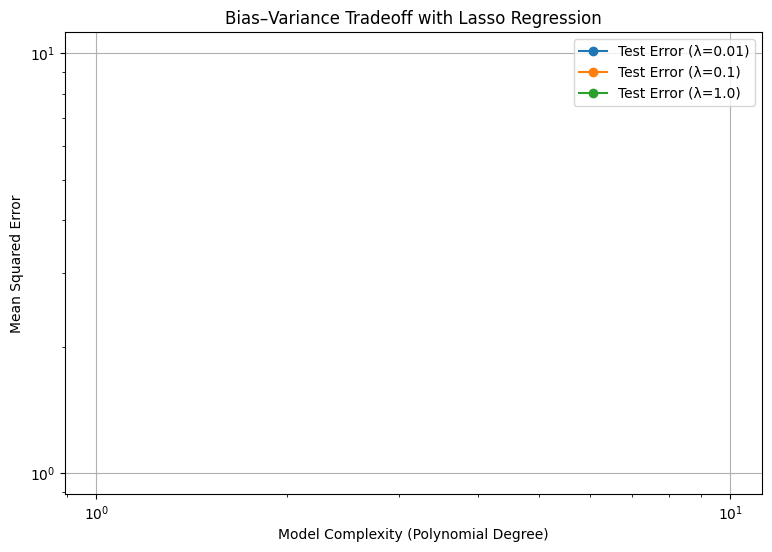

In [ ]:
# Using Lasso Regression 

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(-3, 3, 100)
y = 0.5 * X**3 - X**2 + X + np.random.randn(100) * 3

X_train, X_test = X[:70], X[70:]
y_train, y_test = y[:70], y[70:]

def polynomial_features(x, degree):
    return np.vstack([x**i for i in range(degree + 1)]).T


def lasso_train_and_evaluate(degree, alpha, lr=0.01, epochs=3000):
    Xtr = polynomial_features(X_train, degree)
    Xte = polynomial_features(X_test, degree)
 
    n, m = Xtr.shape
    w = np.zeros(m)

    for _ in range(epochs):
        y_pred = Xtr @ w
        dw = (-2 / n) * (Xtr.T @ (y_train - y_pred)) + alpha * np.sign(w)
        w -= lr * dw

    ytr_pred = Xtr @ w
    yte_pred = Xte @ w

    train_error = np.mean((y_train - ytr_pred) ** 2)
    test_error = np.mean((y_test - yte_pred) ** 2)

    return train_error, test_error, w


degrees = range(1, 5)
alphas = [0.01, 0.1, 1.0]  # Lasso strengths

results = {}

for alpha in alphas:
    train_errors = []
    test_errors = []

    for d in degrees:
        tr_err, te_err, _ = lasso_train_and_evaluate(d, alpha)
        train_errors.append(tr_err)
        test_errors.append(te_err)

    results[alpha] = (train_errors, test_errors)


plt.figure(figsize=(9, 6))

for alpha in alphas:
    tr, te = results[alpha]
    plt.loglog(degrees, te, marker='o', label=f"Test Error (λ={alpha})")

plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared Error")
plt.title("Bias–Variance Tradeoff with Lasso Regression")
plt.legend()
plt.grid(True)
plt.show()

